In [ ]:
!pip install uv
!uv pip install 'git+https://github.com/sgl-project/sglang.git#subdirectory=python&egg=sglang[all]'
!pip install datasets pybase64 pillow
!pip install vllm
# !pip install qwen-vl-utils torchvision

Using Python 3.12.12 environment at: /usr
Resolved 203 packages in 813ms
Prepared 1 package in 51ms
Uninstalled 11 packages in 849ms
Installed 11 packages in 248ms
 - huggingface-hub==0.36.2
 + huggingface-hub==1.7.2
 - llguidance==1.3.0
 + llguidance==0.7.30
 - nvidia-nvshmem-cu12==3.4.5
 + nvidia-nvshmem-cu12==3.3.20
 - opencv-python-headless==4.13.0.92
 + opencv-python-headless==4.10.0.84
 - outlines-core==0.2.11
 + outlines-core==0.1.26
 - torch==2.10.0
 + torch==2.9.1
 - torchaudio==2.10.0
 + torchaudio==2.9.1
 - torchvision==0.25.0
 + torchvision==0.24.1
 - transformers==4.57.6
 + transformers==5.3.0
 - triton==3.6.0
 + triton==3.5.1
 - xgrammar==0.1.32
 + xgrammar==0.1.27
  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached llguidance-1.3.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
  Using cached outlines_core-0.2.11-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.8 kB)
  Using cached xgrammar-

In [ ]:
import sglang as sgl
import time
from openai import OpenAI
import subprocess
import urllib.request
import os
import pandas as pd
import datasets
import pybase64
# import pillow
import urllib.request


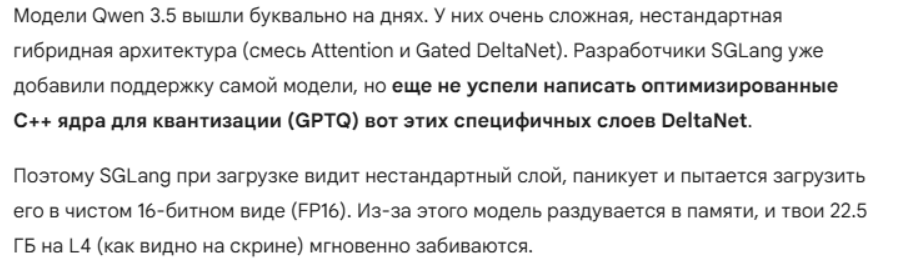

возникла проблема с Qwen3.5-35B-A3B-GPTQ-Int4
из-за того что сгланг подкачал, то GPTQ квантизация не получилась и раздулась оч силь и заняла всю VRAM

In [ ]:
# эмпирическим путем пришел, что модель займет около 14 ГБ VRAM, но квантизированные веса плохо прочитались и раскрылись с большим весом и забили память гпу
# а еще надо использовать gptq_marlin так как L4 gpu работает быстро с bf16

In [ ]:
# Запускаем 4B модель БЕЗ флагов квантизации
!nohup python -m sglang.launch_server \
  --model-path Qwen/Qwen3.5-4B \
  --port 8000 \
  --tp-size 1 \
  --mem-fraction-static 0.85 \
  --context-length 16384 > server.log 2>&1 &

In [ ]:
!tail -n 50 server.log

[2026-03-21 22:17:04] Transformers version 5.3.0 is used for model type qwen3_5. If you experience issues related to RoPE parameters, they may be due to incompatibilities between Transformers >=5.0.0 and some models. You can try downgrading to transformers==4.57.1 as a workaround.
[2026-03-21 22:17:08] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
[2026-03-21 22:17:14] INFO utils.py:164: NumExpr defaulting to 12 threads.
[2026-03-21 22:17:14] Using default HuggingFace chat template with detected content format: openai
[2026-03-21 22:17:14] INFO utils.py:164: NumExpr defaulting to 12 threads.
[2026-03-21 22:17:19] Transformers version 5.3.0 is used for model type qwen3_5. If you experience issues related to RoPE parameters, they may be due to incompatibilities between Transformers >=5.0.0 and some models. You can try downgrading to transformers==4.57.1 as a workaround.
[2026-03-21 22:17:19] Warni

In [ ]:
# [2026-03-21 21:05:47] KV Cache is allocated. #tokens: 171936, K size: 2.62 GB, V size: 2.62 GB

In [ ]:

# Подключаемся к локальному бэкенду
sgl.set_default_backend(sgl.RuntimeEndpoint("http://localhost:8000"))

# Декоратор sgl.function - это главная фишка фронтенда SGLang
@sgl.function
def analyze_document(s, document_text, question):
    s += sgl.system("You are an expert data analyst. Read the context and answer questions precisely.")
    s += sgl.user(f"Context: {document_text}\n\nQuestion: {question}")
    s += sgl.assistant(sgl.gen("answer", max_tokens=150, temperature=0.1))

# Имитируем длинный документ (около 2500-3000 токенов)
huge_document = """
SGLang is a structured generation language designed for large language models (LLMs) and vision-language models (VLMs).
It makes your interaction with models faster and more controllable.
Under the hood, SGLang uses RadixAttention, an algorithm that automatically caches the Key-Value (KV) tensors of past prompts.
This means if multiple requests share the same system prompt or document, SGLang only computes the shared part once.
""" * 50 # Умножаем текст, чтобы сделать его длинным

questions = [
    "What is SGLang?",
    "What algorithm does SGLang use under the hood?",
    "Does SGLang compute shared prompts multiple times?",
    "Summarize the main benefit of SGLang in one sentence."
]

print(" Starting SGLang RadixAttention Benchmark...\n")

for i, q in enumerate(questions):
    start_time = time.time()

    # Отправляем запрос
    state = analyze_document.run(
        document_text=huge_document,
        question=q
    )

    total_time = time.time() - start_time

    print(f"--- Request {i+1} ---")
    print(f"Question: {q}")
    print(f"Time taken: {total_time:.4f} seconds")
    print(f"Answer: {state['answer'].strip()}\n")

 Starting SGLang RadixAttention Benchmark...

--- Request 1 ---
Question: What is SGLang?
Time taken: 0.0005 seconds
Answer: <think>

</think>

SGLang is a structured generation language designed for large language models (LLMs) and vision-language models (VLMs). It aims to make interactions with these models faster and more controllable. Under the hood, it utilizes RadixAttention, an algorithm that automatically caches the Key-Value (KV) tensors of past prompts. This caching mechanism ensures that if multiple requests share the same system prompt or document, SGLang only computes the shared part once, thereby improving efficiency.

--- Request 2 ---
Question: What algorithm does SGLang use under the hood?
Time taken: 0.0004 seconds
Answer: <think>

</think>

SGLang uses **RadixAttention** under the hood. This is an algorithm that automatically caches the Key-Value (KV) tensors of past prompts to improve efficiency.

--- Request 3 ---
Question: Does SGLang compute shared prompts multip

In [ ]:
# если надо освободить порт:
!pkill -9 -f sglang
!fuser -k 8000/tcp


SyntaxError: invalid syntax (1467209639.py, line 1)

Qwen3.5 использует гибридный кэш: KV-кэш для Attention и Mamba-like кэш для слоев DeltaNet

В логах можно увидеть преаллокацию для KV-cahce и для Mamba_cache

In [ ]:
!nvidia-smi

Sat Mar 21 22:03:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   46C    P8             17W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Стучимся в наш работающий сервер
client = OpenAI(base_url="http://localhost:8000/v1", api_key="EMPTY")

# Ссылка на тестовую картинку (милый котик)
image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg"

print("Отправляем мультимодальный запрос")

try:
    response = client.chat.completions.create(
        model="Qwen/Qwen3.5-4B", # Точно имя из логов запуска
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Describe this image in detail."},
                    {"type": "image_url", "image_url": {"url": image_url}}
                ]
            }
        ],
        max_tokens=150
    )
    print("\n Ответ модели:")
    print(response.choices[0].message.content)

except Exception as e:
    print("\n Ошибка API")
    print(e)

Отправляем мультимодальный запрос

 Ошибка API
Error code: 500 - {'object': 'error', 'message': "Internal server error: An exception occurred while loading IMAGE data at index 0: Error while loading data ImageData(url='https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg', detail='auto', max_dynamic_patch=None): 403 Client Error: Forbidden for url: https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg", 'type': 'InternalServerError', 'param': None, 'code': 500}


К сожалению это только текстовая модель ==(((
Возьмем Qwen/Qwen2-VL-2B-Instruct и проведем бенчмарк опираясь на https://docs.sglang.io/developer_guide/bench_serving.html#quick-start

In [ ]:
import subprocess
import time
import urllib.request
import os
import sys

# 0. Проверка импортов (то, о чем ты просил)
try:
    import sglang
    print(" Модуль sglang найден.")
except ImportError:
    print(" ОШИБКА: sglang не установлен. Выполняю установку...")
    os.system("pip install uv && uv pip install 'git+https://github.com/sgl-project/sglang.git#subdirectory=python&egg=sglang[all]'")

# 1. Жесткая зачистка старых процессов
print(" Очистка портов и памяти...")
os.system("pkill -9 -f sglang")
os.system("pkill -9 -f vllm")
os.system("fuser -k 8001/tcp")

# 2. Запуск сервера
print( "Запускаем SGLang сервер на порту 8001...")
server_cmd = [
    "python3", "-m", "sglang.launch_server",
    "--model-path", "Qwen/Qwen2-VL-2B-Instruct",
    "--port", "8001",
    "--tp-size", "1",
    "--mem-fraction-static", "0.8" # Немного снизил, чтобы дать больше места системе
]

# Логи пишем в отдельный файл
log_file = 'server_debug_8001.log'
server_process = subprocess.Popen(server_cmd, stdout=open(log_file, 'w'), stderr=subprocess.STDOUT)

# 3. Ожидание готовности
print(" Ждем готовности сервера (смотрим в логи)...")
is_ready = False
start_wait = time.time()

for i in range(180):
    # Каждые 10 секунд выводим последнюю строку из лога, чтобы видеть прогресс
    if i % 10 == 0 and i > 0:
        last_line = subprocess.getoutput(f"tail -n 1 {log_file}")
        print(f"   [{i}с] Статус: {last_line}")

    try:
        urllib.request.urlopen("http://127.0.0.1:8001/v1/models")
        is_ready = True
        print(f" СЕРВЕР ГОТОВ! (заняло {int(time.time() - start_wait)}с)")
        break
    except Exception:
        # Проверяем, не умер ли сам процесс
        if server_process.poll() is not None:
            print(" КРИТИЧЕСКАЯ ОШИБКА: Процесс сервера завершился досрочно!")
            break
        time.sleep(1)

if not is_ready:
    print("\n" + "="*50)
    print("❌ ОШИБКА ЗАПУСКА. ВЫВОЖУ ПОЛНЫЙ ЛОГ СЕРВЕРА:")
    print("="*50)
    with open(log_file, "r") as f:
        print(f.read())
    print("="*50)
    server_process.kill()
else:
    # 4. Бенчмарк
    print(" Запуск бенчмарка...")
    bench_cmd = [
        "python3", "-m", "sglang.bench_serving",
        "--backend", "sglang-oai-chat",
        "--base-url", "http://127.0.0.1:8001",
        "--model", "Qwen/Qwen2-VL-2B-Instruct",
        "--dataset-name", "image",
        "--num-prompts", "20", # Уменьшил количество для быстрой проверки
        "--output-file", "sglang_results.jsonl"
    ]
    subprocess.run(bench_cmd)

    server_process.terminate()
    print("Готово.")

In [ ]:
# 1. Жесткая зачистка старых процессов (на всякий случай)
os.system("pkill -9 -f sglang")
os.system("pkill -9 -f vllm")

# 2. Запуск сервера на новом порту 8001
print(" Запускаем SGLang сервер на порту 8001...")
server_cmd = [
    "python3", "-m", "sglang.launch_server",
    "--model-path", "Qwen/Qwen2-VL-2B-Instruct",
    "--port", "8001",
    "--tp-size", "1",
    "--mem-fraction-static", "0.85"
]

# Запускаем сервер в фоне, логи пишем в файл
server_process = subprocess.Popen(server_cmd, stdout=open('server_8001.log', 'w'), stderr=subprocess.STDOUT)

# 3. Умное ожидание готовности (без глупых таймаутов)
print(" Ждем инициализации модели и загрузки весов в GPU (около 1-2 минут)...")
is_ready = False
for i in range(180): # Ждем до 3 минут
    try:
        # Пингуем системный эндпоинт OpenAI API
        urllib.request.urlopen("http://127.0.0.1:8001/v1/models")
        is_ready = True
        print(f" Сервер успешно поднялся за {i} секунд!")
        break
    except Exception:
        time.sleep(1)

if not is_ready:
    print(" Сервер не поднялся. логи для отладки:")
    os.system("tail -n 20 server_8001.log")
    server_process.kill()
else:
    # 4. Запуск официального бенчмарка из гайда
    print(" Запускаем стресс-тест bench_serving (50 запросов с картинками)...\n")
    bench_cmd = [
        "python3", "-m", "sglang.bench_serving",
        "--backend", "sglang-oai-chat",
        "--base-url", "http://127.0.0.1:8001",
        "--model", "Qwen/Qwen2-VL-2B-Instruct",
        "--dataset-name", "image",
        "--image-count", "1",
        "--image-resolution", "720p",
        "--random-input-len", "64",
        "--random-output-len", "128",
        "--num-prompts", "50",
        "--output-file", "sglang_results.jsonl"
    ]

    # Запускаем бенчмарк и ждем окончания
    subprocess.run(bench_cmd)

    # 5. Убиваем сервер после тестов, чтобы освободить GPU
    print("\n Бенчмарк завершен. Останавливаем сервер SGLang...")
    server_process.terminate()
    print(" Порт 8001 и видеопамять L4 снова свободны!")



 Запускаем SGLang сервер на порту 8001...
 Ждем инициализации модели и загрузки весов в GPU (около 1-2 минут)...
 Сервер не поднялся. логи для отладки:


In [ ]:
print("\n== Финальные метрики SGLang ===")
try:
    df = pd.read_json("sglang_results.jsonl", lines=True)
    print(f"Request Throughput (запросов/сек): {df['request_throughput'].iloc[0]:.2f}")
    print(f"Output Throughput (токенов/сек):   {df['output_throughput'].iloc[0]:.2f}")
    print(f"TTFT Median (мс):                  {df['mean_ttft_ms'].iloc[0]:.2f}")
except Exception as e:
    print("Не удалось прочитать файл метрик. Проверь, установились ли библиотеки datasets и pybase64.")


=== 🏆 Финальные метрики SGLang ===
Request Throughput (запросов/сек): 1.61
Output Throughput (токенов/сек):   100.93
TTFT Median (мс):                  17864.43


Теперь на vLLM

In [ ]:
!pip install vllm
# !pip install qwen-vl-utils torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.2/433.2 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 149.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3

In [ ]:
!pip install vllm qwen-vl-utils torchvision --no-build-isolation

In [ ]:
# !pip install flash-attn --no-build-isolation --prefer-binary
# ставим без комплияции флэш аттенш, потому что qwen 2.0 старый, а vllm версия новая и пытается запустить V1 Engine

# пришлось ставить старый движок

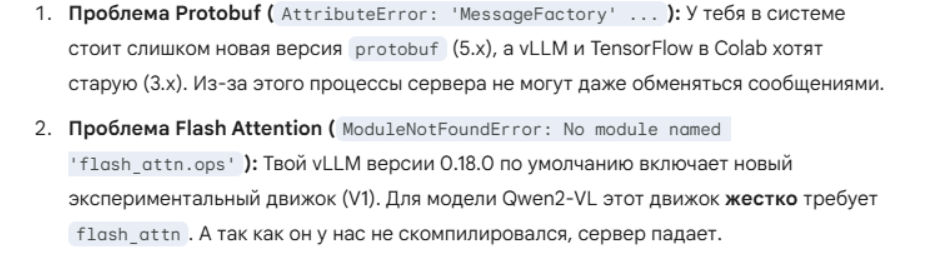

In [ ]:
import subprocess
import time
import urllib.request
import os
import pandas as pd

# 1. Исправляем Protobuf и зависимости прямо в коде
print(" Исправляем зависимости (Protobuf)...")
os.system('pip install "protobuf<5.0.0" qwen-vl-utils --force-reinstall -q')
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

# 2. Жесткая зачистка
print(" Очистка портов и старых логов...")
os.system("pkill -9 -f sglang")
os.system("pkill -9 -f vllm")
os.system("fuser -k 8001/tcp")
if os.path.exists('vllm_8001.log'):
    os.remove('vllm_8001.log') # Чистим файл, чтобы видеть только свежие логи

# 3. Настройка переменных окружения (ОТКЛЮЧАЕМ V1)
env = os.environ.copy()
# В версии 0.18.0 vLLM может использовать разные имена для этого флага, ставим все
env["VLLM_USE_V1"] = "0"
env["VLLM_V1"] = "0"
env["VLLM_USE_V1_ENGINE"] = "0"
env["VLLM_ATTENTION_BACKEND"] = "FLASHINFER" # Используем FlashInfer вместо Flash-Attn

# 4. Запуск сервера vLLM (ОДИН РАЗ)
print(" Запускаем vLLM сервер (Stable V0 Engine) на порту 8001...")
server_cmd = [
    "python3", "-m", "vllm.entrypoints.openai.api_server",
    "--model", "Qwen/Qwen2-VL-2B-Instruct",
    "--port", "8001",
    "--max-model-len", "4096",
    "--gpu-memory-utilization", "0.80",
    "--trust-remote-code"
]

log_file = 'vllm_8001.log'
server_process = subprocess.Popen(
    server_cmd,
    stdout=open(log_file, 'w'),
    stderr=subprocess.STDOUT,
    env=env
)

# 5. Умное ожидание
print("Ждем инициализации vLLM (до 5 минут)...")
is_ready = False
start_time = time.time()

for i in range(300):
    if i % 20 == 0 and i > 0:
        last_log = subprocess.getoutput(f"tail -n 1 {log_file}")
        print(f"   [⏳ {i}с] Статус: {last_log}")

    try:
        urllib.request.urlopen("http://127.0.0.1:8001/v1/models")
        is_ready = True
        print(f" vLLM ПОДНЯЛСЯ! (заняло {int(time.time() - start_time)}с)")
        break
    except Exception:
        if server_process.poll() is not None:
            print(" СЕРВЕР УПАЛ ДОСРОЧНО!")
            break
        time.sleep(1)

if is_ready:
    # 6. ЗАПУСК БЕНЧМАРКА
    print(" Запускаем стресс-тест bench_serving...")
    bench_cmd = [
        "python3", "-m", "sglang.bench_serving",
        "--backend", "vllm-chat",
        "--base-url", "http://127.0.0.1:8001",
        "--model", "Qwen/Qwen2-VL-2B-Instruct",
        "--dataset-name", "image",
        "--num-prompts", "50",
        "--output-file", "vllm_results.jsonl"
    ]
    subprocess.run(bench_cmd)

    server_process.terminate()

    print("\n===  Результаты vLLM ===")
    try:
        df = pd.read_json("vllm_results.jsonl", lines=True)
        print(f"Throughput (токенов/сек): {df['output_throughput'].iloc[0]:.2f}")
        # Пробуем достать TTFT
        ttft = df.get('ttft_median', [0])[0]
        print(f"TTFT Median (мс):         {ttft*1000:.2f}")
    except Exception as e:
        print(f"Ошибка чтения результатов: {e}")
else:
    print("\n" + "!"*60)
    print("❌ ОШИБКА. ВЫВОЖУ ПОСЛЕДНИЕ 30 СТРОК ЛОГА:")
    os.system(f"tail -n 30 {log_file}")
    server_process.kill()

🛠️ Исправляем зависимости (Protobuf)...
🧹 Очистка портов и старых логов...
🚀 Запускаем vLLM сервер (Stable V0 Engine) на порту 8001...
⏳ Ждем инициализации vLLM (до 5 минут)...
🛑 СЕРВЕР УПАЛ ДОСРОЧНО!

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
❌ ОШИБКА. ВЫВОЖУ ПОСЛЕДНИЕ 30 СТРОК ЛОГА:
